In [4]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [205]:
sale  = pd.read_csv(r"C:\Users\DELL\Downloads\Data1\Sales Transaction.csv")


# step-2

# Data Inspect

In [72]:
sale.head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
1,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom
2,581475,12/9/2019,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom
3,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom
4,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom


In [89]:
sale.tail()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
536345,C536548,12/1/2018,22168,Organiser Wood Antique White,18.96,-2,12472.0,Germany
536346,C536548,12/1/2018,21218,Red Spotty Biscuit Tin,14.09,-3,12472.0,Germany
536347,C536548,12/1/2018,20957,Porcelain Hanging Bell Small,11.74,-1,12472.0,Germany
536348,C536548,12/1/2018,22580,Advent Calendar Gingham Sack,16.35,-4,12472.0,Germany
536349,C536548,12/1/2018,22767,Triple Photo Frame Cornice,20.45,-2,12472.0,Germany


In [74]:
sale.shape

(536350, 8)

In [18]:
sale.size

4290800

In [90]:
sale.columns

Index(['TransactionNo', 'Date', 'ProductNo', 'ProductName', 'Price',
       'Quantity', 'CustomerNo', 'Country'],
      dtype='object')

# Step - 3

# Data Cleaning

In [91]:
sale.isnull().sum()

TransactionNo     0
Date              0
ProductNo         0
ProductName       0
Price             0
Quantity          0
CustomerNo       55
Country           0
dtype: int64

In [84]:
sale = sale.fillna({'CustomerNo' : 'NA'})

In [85]:
sale = sale.isnull().sum()
sale

np.int64(0)

# step 4 EDA TASK

In [ ]:
# Sales Tre# nd Analysis

In [45]:
# Step 1 : Create a Sales column

In [61]:
# step -1  Convert Date Column to datetime (if not already)

In [95]:
## Add a new column 'Revenue'
sale['Revenue'] = sale['Price'] * sale['Quantity']

# Check the first few rows
sale.head()



,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,Revenue
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom,257.64
1,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom,383.40
2,581475,12/9/2019,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom,138.36
3,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom,127.80
4,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom,71.64


In [96]:
# Calulate Revene 


In [100]:
Product_Revenue  = sale.groupby('ProductName')['Revenue'].sum().reset_index().sort_values(by='Revenue', ascending=False).head()
Product_Revenue 

,ProductName,Revenue
2489,Popcorn Holder,583286.51
3685,World War 2 Gliders Asstd Designs,557170.43
2210,Paper Craft Little Birdie,501359.05
828,Cream Hanging Heart T-Light Holder,451401.70
204,Assorted Colour Bird Ornament,420743.70


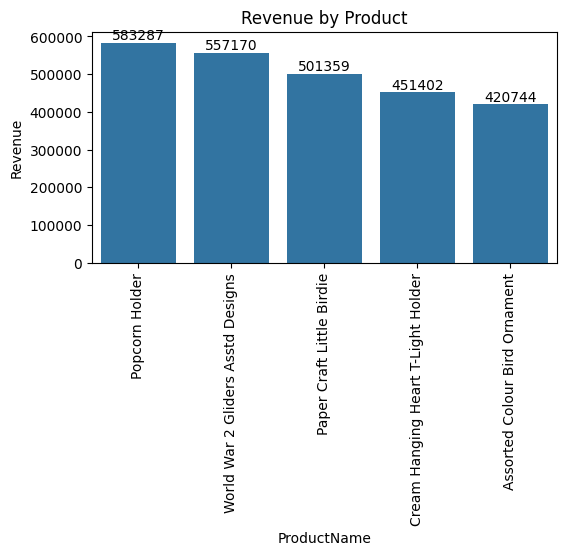

In [117]:
plt.figure(figsize =(6,3))

ax = sns.barplot(x='ProductName', y='Revenue', data=Product_Revenue)
plt.xticks(rotation=90)   # rotate labels if product names are long
plt.title("Revenue by Product")
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')  
plt.show()


In [118]:
# Country wise Revenue

In [134]:
Country =sale.groupby('Country')['Revenue'].sum().reset_index().sort_values(by='Revenue',ascending=False).head(10)

C:\Users\DELL\AppData\Local\Temp\ipykernel_3336\3444477603.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Revenue', y='Country', data=Country, palette="viridis")


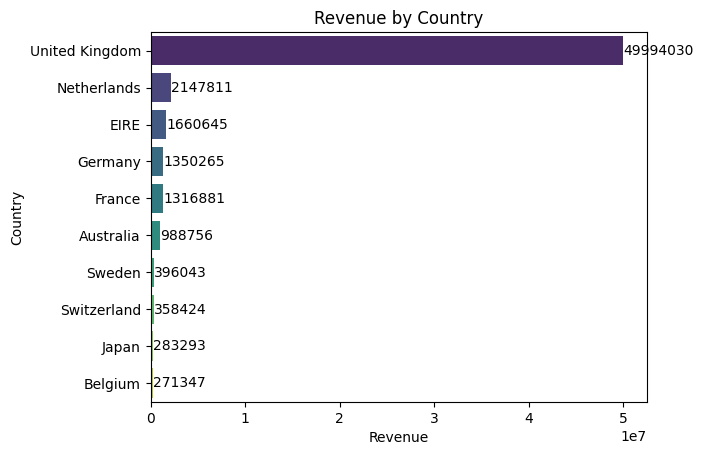

In [148]:

ax = sns.barplot(x='Revenue', y='Country', data=Country, palette="viridis")

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.title("Revenue by Country")
plt.show()


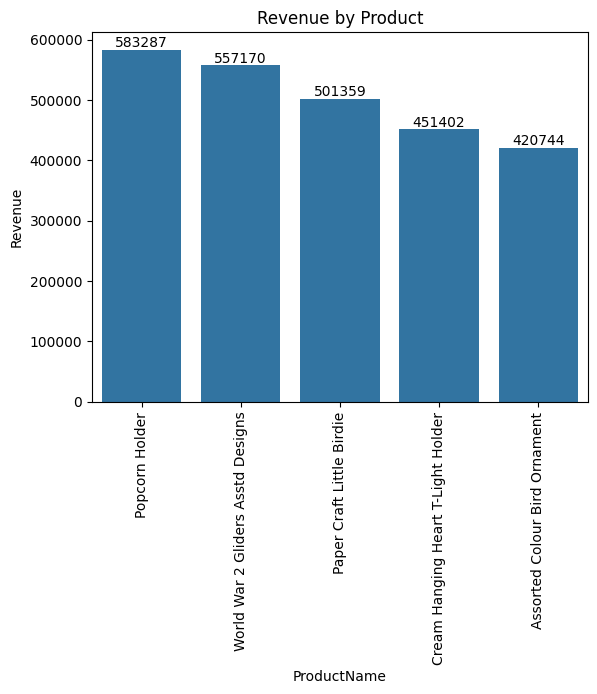

In [147]:

ax = sns.barplot(x='ProductName', y='Revenue', data=Product_Revenue)

# Rotate x-axis labels if needed
plt.xticks(rotation=90)
plt.title("Revenue by Product")

# Add data labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')   # format without decimals

plt.show()


In [140]:
# bottom 5 sales

In [141]:
sale.columns

Index(['TransactionNo', 'Date', 'ProductNo', 'ProductName', 'Price',
       'Quantity', 'CustomerNo', 'Country', 'Revenue'],
      dtype='object')

In [154]:
data1 = sale.groupby('Country')['Revenue'].sum().reset_index().sort_values(by='Revenue' , ascending=True).head(5)


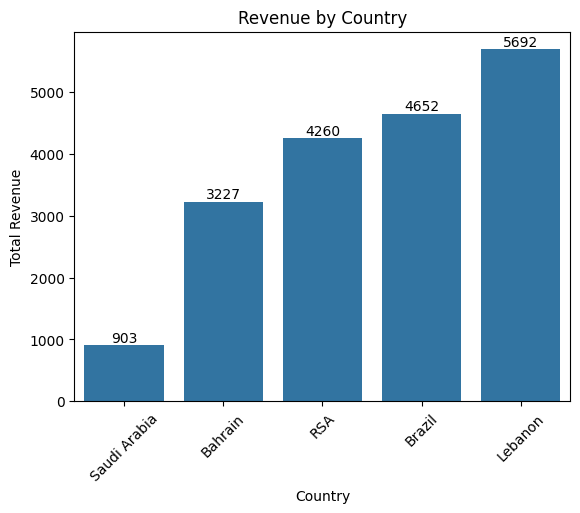

In [155]:

ax = sns.barplot(x='Country', y='Revenue', data=data1)

# Add labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.title("Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()


In [165]:
# Group by Date and sum Revenue
Date_Revenue = sale.groupby('Date')['Revenue'].sum().reset_index().sort_values(by='Revenue',ascending=False).head()
Date_Revenue 
#

,Date,Revenue
103,12/9/2019,604502.11
54,11/14/2019,561052.51
289,9/20/2019,548012.49
46,10/5/2019,515992.08
34,10/20/2019,469122.96


In [ ]:
# Total Qty by Product

In [187]:
Total_qty = sale.groupby('Country')['Quantity'].sum().head()
Total_qty

Country
Australia    85199
Austria       5585
Bahrain        260
Belgium      23665
Brazil         353
Name: Quantity, dtype: int64

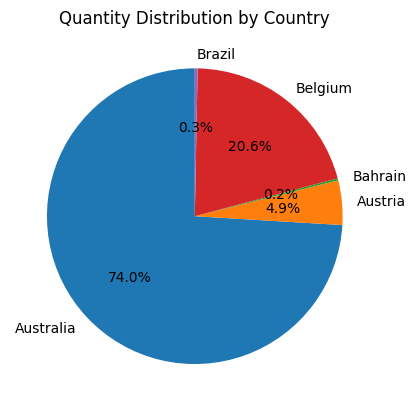

In [188]:
plt.pie(
    Total_qty.values,          # numeric values
    labels=Total_qty.index,    # category labels
    autopct='%1.1f%%', 
    startangle=90
)
plt.title("Quantity Distribution by Country")
plt.show()

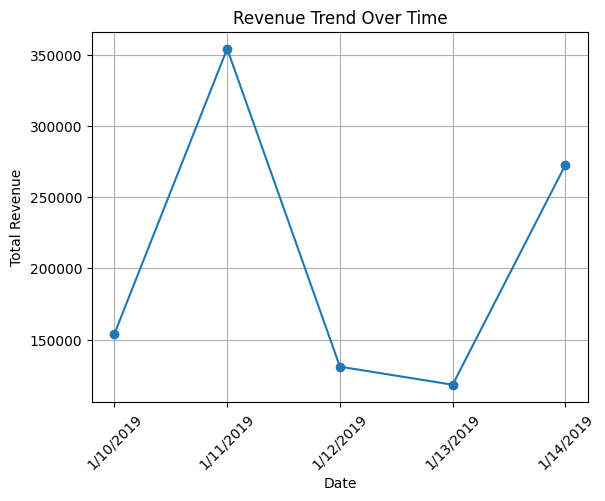

In [199]:
# Group by Date and sum Revenue
Date_Revenue = sale.groupby('Date')['Revenue'].sum().reset_index().head(5)

# Sort by Date to ensure chronological order
Date_Revenue = Date_Revenue.sort_values(by='Date')

# Plot line chart

plt.plot(Date_Revenue['Date'], Date_Revenue['Revenue'], marker='o', linestyle='-')

plt.title("Revenue Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)   # rotate dates for readability
plt.grid(True)
plt.show()


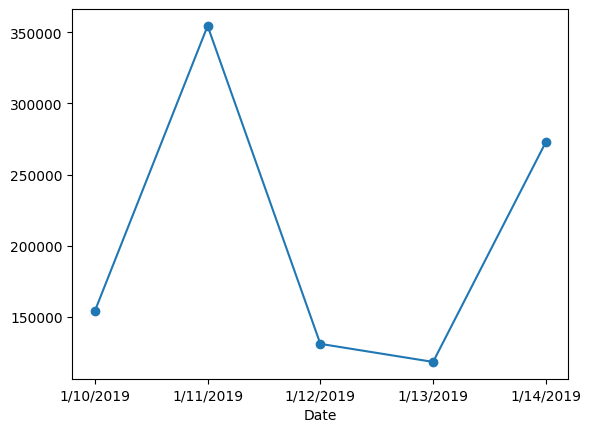

In [204]:
date_revenue  = sale.groupby('Date')['Revenue'].sum().reset_index().head(5)
date_revenue = date_revenue.sort_values(by='Date')

plt.plot(date_revenue['Date'], date_revenue['Revenue'], marker='o', linestyle="-")
plt.xlabel("Revenue Trend Over Time")
plt.xlabel("Date")
plt.show()

In [ ]:

# Returns the total unique product

In [206]:
sale['ProductName'].nunique()

3768

In [207]:
sale['ProductName'].unique()

array(['Set Of 2 Wooden Market Crates',
       'Christmas Star Wish List Chalkboard', 'Storage Tin Vintage Leaf',
       ..., 'Girly Pink Tool Set', 'Pink Marshmallow Scarf Knitting Kit',
       'Porcelain Hanging Bell Small'], shape=(3768,), dtype=object)

In [211]:
df1 = sale[sale['ProductName'] == 'Set Of 2 Wooden Market Crates']
df1


,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
10384,580894,12/6/2019,22485,Set Of 2 Wooden Market Crates,6.19,12,13408.0,United Kingdom
23883,580097,12/1/2019,22485,Set Of 2 Wooden Market Crates,7.24,2,14216.0,United Kingdom
26557,579676,11/30/2019,22485,Set Of 2 Wooden Market Crates,6.19,2,17502.0,United Kingdom
26653,579690,11/30/2019,22485,Set Of 2 Wooden Market Crates,7.24,1,15060.0,United Kingdom
...,...,...,...,...,...,...,...,...
495516,539739,12/21/2018,22485,Set Of 2 Wooden Market Crates,36.38,1,15739.0,United Kingdom
502252,539418,12/17/2018,22485,Set Of 2 Wooden Market Crates,23.32,2,17007.0,United Kingdom
519377,537843,12/8/2018,22485,Set Of 2 Wooden Market Crates,23.32,2,15713.0,United Kingdom
526140,537265,12/6/2018,22485,Set Of 2 Wooden Market Crates,23.32,2,15919.0,United Kingdom
